<a href="https://colab.research.google.com/github/MindfulTechie-06/ai-ml-coursework/blob/main/Route_DFS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Problem 3: Checking Routes Between Cities Using DFS

In [1]:
import collections

class Graph:
    def __init__(self):
        self.adj = collections.defaultdict(list)

    def add_edge(self, u, v):
        self.adj[u].append(v)
        self.adj[v].append(u) # Assuming an undirected graph (roads go both ways)

    def dfs_path_exists(self, start, end, visited=None):
        if visited is None:
            visited = set()

        visited.add(start)

        if start == end:
            return True

        for neighbor in self.adj[start]:
            if neighbor not in visited:
                if self.dfs_path_exists(neighbor, end, visited):
                    return True
        return False

    def dfs_find_component(self, start_node, visited, component):
        visited.add(start_node)
        component.append(start_node)

        for neighbor in self.adj[start_node]:
            if neighbor not in visited:
                self.dfs_find_component(neighbor, visited, component)

    def find_connected_components(self):
        visited = set()
        components = []
        for node in self.adj:
            if node not in visited:
                current_component = []
                self.dfs_find_component(node, visited, current_component)
                components.append(current_component)
        return components

# --- Example Usage ---

### 1. Checks whether a route exists between two given cities.

In [2]:
g = Graph()
g.add_edge('A', 'B')
g.add_edge('B', 'C')
g.add_edge('C', 'D')
g.add_edge('E', 'F')

print("Graph edges:")
for city, connected_cities in g.adj.items():
    print(f"{city}: {', '.join(connected_cities)}")

# Test route existence
start_city = 'A'
end_city = 'D'
if g.dfs_path_exists(start_city, end_city):
    print(f"\nRoute exists between {start_city} and {end_city}")
else:
    print(f"\nNo route exists between {start_city} and {end_city}")

start_city = 'A'
end_city = 'F'
if g.dfs_path_exists(start_city, end_city):
    print(f"Route exists between {start_city} and {end_city}")
else:
    print(f"No route exists between {start_city} and {end_city}")

Graph edges:
A: B
B: A, C
C: B, D
D: C
E: F
F: E

Route exists between A and D
No route exists between A and F


### 2. Finds all separate groups of cities that are connected to each other.

In [3]:
connected_components = g.find_connected_components()
print("\nConnected Components:")
for i, component in enumerate(connected_components):
    print(f"Component {i+1}: {', '.join(component)}")

# Example with more disconnected components
g2 = Graph()
g2.add_edge('X', 'Y')
g2.add_edge('Y', 'Z')
g2.add_edge('P', 'Q')
g2.add_edge('M', 'N')

print("\nGraph 2 edges:")
for city, connected_cities in g2.adj.items():
    print(f"{city}: {', '.join(connected_cities)}")

connected_components_g2 = g2.find_connected_components()
print("\nConnected Components for Graph 2:")
for i, component in enumerate(connected_components_g2):
    print(f"Component {i+1}: {', '.join(component)}")


Connected Components:
Component 1: A, B, C, D
Component 2: E, F

Graph 2 edges:
X: Y
Y: X, Z
Z: Y
P: Q
Q: P
M: N
N: M

Connected Components for Graph 2:
Component 1: X, Y, Z
Component 2: P, Q
Component 3: M, N


### Visualizing the Road Networks and Connected Components

In [4]:
# Install networkx if not already installed
!pip install networkx


Graph 'g' (A-D, E-F) Connected Components:
  Component 1: A, B, C, D
  Component 2: E, F

Graph 'g2' (X-Y-Z, P-Q, M-N) Connected Components:
  Component 1: X, Y, Z
  Component 2: P, Q
  Component 3: M, N


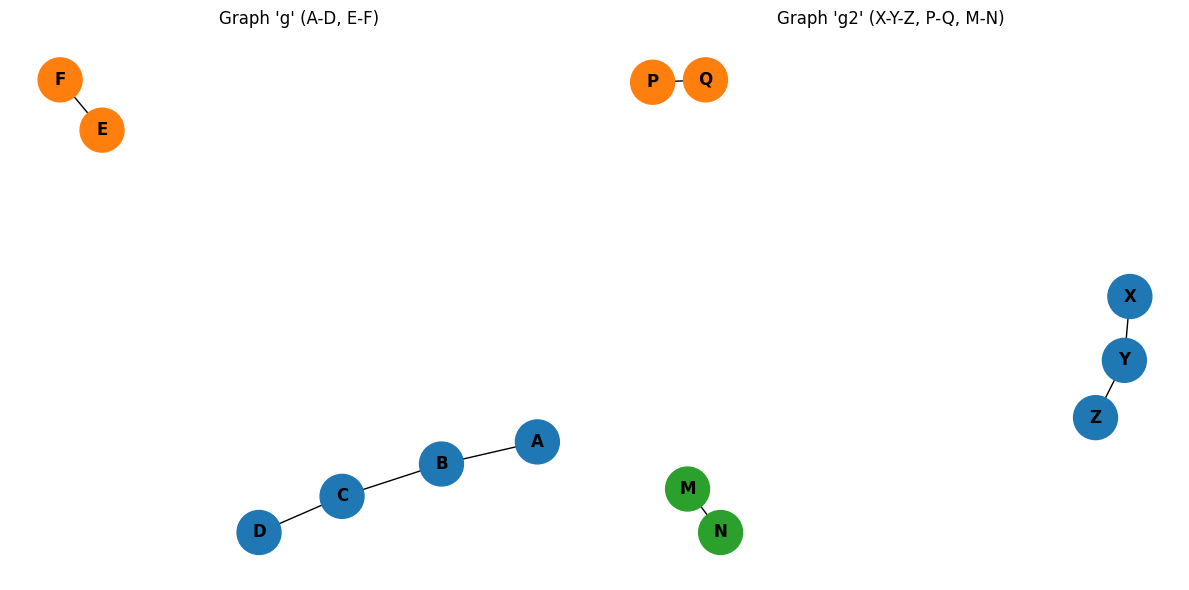

In [7]:
import networkx as nx
import matplotlib.pyplot as plt

def draw_graph_with_components(graph_obj, title="Graph Visualization", ax=None):
    G = nx.Graph()
    # Add nodes and edges from our custom Graph object
    for node, neighbors in graph_obj.adj.items():
        G.add_node(node)
        for neighbor in neighbors:
            G.add_edge(node, neighbor)

    # Find connected components using networkx
    components = list(nx.connected_components(G))

    # Assign a color to each component
    color_map = {}
    # Using 'tab10' colormap for better distinction and correcting the get_cmap usage
    colors = plt.colormaps.get_cmap('tab10') # Corrected: only pass the colormap name
    for i, component in enumerate(components):
        # Use the colormap to get a distinct color for each component index
        for node in component:
            color_map[node] = colors(i % colors.N) # Ensure index is within colormap range

    node_colors = [color_map.get(node) for node in G.nodes()]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))

    pos = nx.spring_layout(G, seed=42) # For consistent layout
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=1000, ax=ax)
    nx.draw_networkx_edges(G, pos, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold', ax=ax)
    ax.set_title(title)
    ax.axis('off')

    print(f"\n{title} Connected Components:")
    for i, comp in enumerate(components):
        print(f"  Component {i+1}: {', '.join(sorted(list(comp)))}")


# Visualize Graph g
# Adjusted figsize to bring graphs closer
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
draw_graph_with_components(g, "Graph 'g' (A-D, E-F)", ax=ax1)

# Visualize Graph g2
draw_graph_with_components(g2, "Graph 'g2' (X-Y-Z, P-Q, M-N)", ax=ax2)

plt.tight_layout()
plt.show()